In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

import pandas as pd
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger

2026-04-22 16:43:27.183693: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 16:43:27.194957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776851007.208702   39422 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776851007.213168   39422 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776851007.223408   39422 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
Load_Path = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/Final/imgsize64/norm/dwt"

In [3]:

train_data = np.load(os.path.join(Load_Path, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(Load_Path, "tow_ids_test_dwt.npz"))
validation_data = np.load(os.path.join(Load_Path, "tow_ids_validation_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_validation = validation_data["X"]
y_validation = validation_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

print(X_train.shape, y_train.shape)
print(X_validation.shape, y_validation.shape)
print(X_test.shape, y_test.shape)


(52661, 32, 32, 3) (52661,)
(22569, 32, 32, 3) (22569,)
(49472, 32, 32, 3) (49472,)


In [4]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))
print("Validation label distribution :", np.unique(y_validation, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1]), array([24073, 28588]))
Test label distribution : (array([0, 1]), array([27375, 22097]))
Validation label distribution : (array([0, 1]), array([10317, 12252]))
Min value: -0.5254788
Max value: 2.4145703


In [5]:
def composite_conv(x, filters, kernel_size, groups=1):

    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        groups=groups
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    return x

In [6]:
def factorized_conv(x, f1, f2):

    x = composite_conv(x, f1, (1,3))

    x = composite_conv(x, f2, (3,1))

    return x

In [7]:
def DGC_block(x):

    # branch 1
    b1 = composite_conv(x, 16, (1,3))
    b2 = composite_conv(x, 16, (3,1))

    concat = layers.Concatenate()([b1, b2])

    conv = composite_conv(concat, 32, (1,1))

    pool = layers.MaxPooling2D((2,2))(conv)

    g1 = composite_conv(pool, 64, (1,3), groups=4)


    # residual branch
    res = composite_conv(x, 32, (1,1))

    res = layers.MaxPooling2D((2,2))(res)

    g2 = composite_conv(res, 64, (3,1), groups=4)


    out = layers.Add()([g1, g2])

    return out

In [8]:
input_layer = layers.Input(shape=(32,32,3))

x_factor = factorized_conv(input_layer, 32, 16)

x_max= layers.MaxPooling2D((2,2))(x_factor)

x_dgc1 = DGC_block(x_max)

x_dgc2 = DGC_block(x_dgc1)

x_comconv = composite_conv(x_dgc2, 32, (1,1))

del x_factor, x_max, x_dgc1, x_dgc2

x_average = layers.GlobalAveragePooling2D()(x_comconv)

x_flatten = layers.Flatten()(x_average)

x_fcon = layers.Dense(128, activation="relu")(x_flatten)

output_layer = layers.Dense(1, activation="sigmoid")(x_fcon)

del x_comconv, x_average, x_flatten, x_fcon

I0000 00:00:1776851009.405932   39422 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
model = models.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,552 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        784 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │        784 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ re_lu_2[0][0],    │
│ (Concatenate)       │ 32)               │            │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      1,056 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │        544 │ max_pooling2d[0]

 Total params: 29,297 (114.44 KB)

 Trainable params: 28,241 (110.32 KB)

 Non-trainable params: 1,056 (4.12 KB)

In [10]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [11]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.debugging.set_log_device_placement(True)

TensorFlow version: 2.19.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
class TrainingLogger(Callback):

    def on_train_begin(self, logs=None):
        print("\nTraining started")
        print("-"*70)
        print("{:<8} {:<12} {:<12} {:<12} {:<12}".format(
            "Epoch","Loss","Accuracy","Val_Loss","Val_Acc"))
        print("-"*70)

    def on_epoch_end(self, epoch, logs=None):

        print("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            epoch+1,
            logs["loss"],
            logs["accuracy"],
            logs["val_loss"],
            logs["val_accuracy"]
        ))

In [13]:
checkpoint = ModelCheckpoint(
    "best_model_tow_idsIMGSIZE64.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0
)

In [14]:
print("\nDataset summary")
print("-"*40)
print("Train samples :", X_train.shape[0])
print("Test samples  :", X_test.shape[0])
print("Validation samples  :", X_validation.shape[0])
print("Image shape   :", X_train.shape[1:])
print("Batch size    :", 16)
print("Epochs        :", 100)
print("-"*40)


Dataset summary
----------------------------------------
Train samples : 52661
Test samples  : 49472
Validation samples  : 22569
Image shape   : (32, 32, 3)
Batch size    : 16
Epochs        : 100
----------------------------------------


In [15]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    validation_dataset  = tf.data.Dataset.from_tensor_slices((X_validation, y_validation))

train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)
validation_dataset = (
    validation_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

In [16]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/50


I0000 00:00:1776851015.905858   50711 service.cc:152] XLA service 0x7f1990002d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776851015.905937   50711 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-04-22 16:43:36.053347: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776851017.030651   50711 cuda_dnn.cc:529] Loaded cuDNN version 91701


  34/3292 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.6623 - loss: 0.6226   

I0000 00:00:1776851022.965803   50711 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3292/3292 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9762 - loss: 0.0710 - val_accuracy: 0.9867 - val_loss: 0.0435
Epoch 2/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9906 - loss: 0.0340 - val_accuracy: 0.9882 - val_loss: 0.0375
Epoch 3/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9927 - loss: 0.0266 - val_accuracy: 0.9916 - val_loss: 0.0325
Epoch 4/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9945 - loss: 0.0219 - val_accuracy: 0.9373 - val_loss: 0.1933
Epoch 5/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9944 - loss: 0.0205 - val_accuracy: 0.9937 - val_loss: 0.0247
Epoch 6/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9955 - loss: 0.0185 - val_accuracy: 0.9948 - val_loss: 0.0210
Epoch 7/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9957 - loss: 0.0165 - val_accuracy: 0.9934 - val_loss: 0.0279
Epoch 8/50
3292/3292 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9960 - loss: 0.0159 - val

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix

# prediksi probabilitas
y_prob = model.predict(test_dataset)

# konversi menjadi label
y_pred = (y_prob > 0.5).astype(int).flatten()

3092/3092 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [18]:
y_true = y_test

In [19]:
cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[26584   791]
 [ 4528 17569]]


In [20]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP + 1e-8)

recall = TP / (TP + FN + 1e-8)

f1 = 2 * precision * recall / (precision + recall + 1e-8)

FPR = FP / (FP + TN + 1e-8)

FNR = FN / (FN + TP + 1e-8)

In [21]:
print("\nEvaluation Metrics")
print("-------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nIDS Specific Metrics")
print("-------------------")

print("FPR:", FPR)
print("FNR:", FNR)


Evaluation Metrics
-------------------
Accuracy : 0.892484637774903
Precision: 0.9569172113284548
Recall   : 0.7950853056972461
F1-score : 0.8685270731745695

IDS Specific Metrics
-------------------
FPR: 0.028894977168939216
FNR: 0.20491469430230125


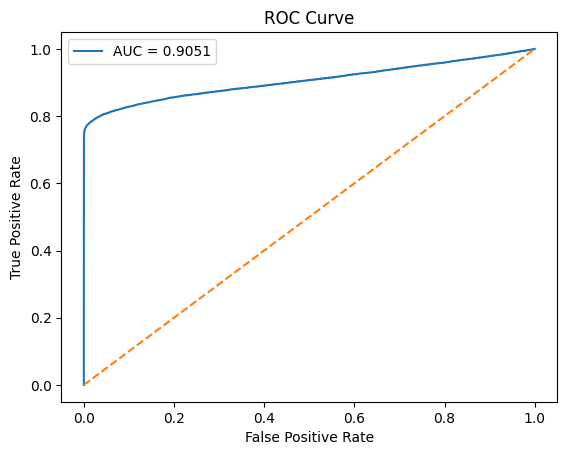

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()